# Russia-Ukraine War Losses Dataset (2022-Present)
### Exploratory Data Analysis (EDA) — Individual Data Analysis Project

Student Name: Riyadh Ahmed Al-Malki
**Date:** July 2026


## Step 1: Choose a Dataset

**Dataset Title:**
2022 Ukraine-Russia War Dataset — Personnel & Equipment Losses

**Source Link:**
- GitHub: https://github.com/PetroIvaniuk/2022-Ukraine-Russia-War-Dataset

**Short Description:**
This dataset documents, on a daily basis, the officially reported Russian losses in the Russia-Ukraine war, starting from the full-scale invasion on 2022-02-25 up to the latest available update. It is sourced from official reports by the General Staff of the Armed Forces of Ukraine and the Ministry of Defence of Ukraine. It has two main parts: Personnel Losses and Equipment Losses (15+ equipment categories: tanks, aircraft, helicopters, artillery, drones, naval ships, etc.). The data is cumulative and updated daily.

**Why I Selected It:**
I selected this dataset because it is real, live data (updated daily up to the present moment) documenting an ongoing regional/global war with major global impact. It has a clear time-series story (escalation and slowdown of losses across different war phases), and it presents realistic data-cleaning challenges, which makes it excellent material for applying a complete data analysis workflow.


## Step 2: Problem Definition

**What is the dataset about?**
A daily time series of officially reported Russian losses in the Russia-Ukraine war, split into human losses (killed, prisoners of war) and military equipment losses (tanks, APCs, aircraft, drones, etc.).

**Main questions we will explore:**
1. How have losses (personnel and equipment) evolved over time since the war began?
2. Which equipment categories suffered the most losses, and how are different categories related?
3. Are there days/periods with exceptional (outlier) losses compared to the daily average?
4. What is the relationship between daily personnel losses and daily equipment losses?
5. Which reported combat directions show up most often as the "greatest losses direction", and where are they located geographically?

**Expected Insights:**
We expect to find a sharp and irregular increase in the pace of losses during the early stages of the war, followed by different patterns of escalation and slowdown depending on the war's phases. We also expect a strong correlation between certain equipment categories (like tanks and APCs) due to their combined use in the same type of battles.


## Step 3: Data Loading & Structure

We will load two JSON files directly from the official GitHub repository (personnel losses and equipment losses), then explore the structure of each before merging and cleaning.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import urllib.request

# إعدادات العرض العامة للرسومات والجداول
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# روابط البيانات الرسمية (ملفات JSON خام من GitHub)
PERSONNEL_URL = "https://raw.githubusercontent.com/PetroIvaniuk/2022-Ukraine-Russia-War-Dataset/main/data/russia_losses_personnel.json"
EQUIPMENT_URL = "https://raw.githubusercontent.com/PetroIvaniuk/2022-Ukraine-Russia-War-Dataset/main/data/russia_losses_equipment.json"

# دالة بسيطة لتحميل وقراءة ملف JSON من رابط مباشرة
def load_json_url(url):
    with urllib.request.urlopen(url) as response:
        return json.loads(response.read().decode())

personnel_raw = load_json_url(PERSONNEL_URL)
equipment_raw = load_json_url(EQUIPMENT_URL)

# تحويل البيانات الخام (قوائم JSON) إلى DataFrame
df_personnel = pd.DataFrame(personnel_raw)
df_equipment = pd.DataFrame(equipment_raw)

print("Data loaded successfully ✅")
print("Personnel records:", len(df_personnel))
print("Equipment records:", len(df_equipment))

Data loaded successfully ✅
Personnel records: 1603
Equipment records: 1603


**First 5 rows of the Personnel dataset:**

In [24]:
# عرض أول 5 صفوف من بيانات الأفراد
df_personnel.head()

,date,day,personnel,personnel*,POW
0,2022-02-25,2,2800,about,0.0
1,2022-02-26,3,4300,about,0.0
2,2022-02-27,4,4500,about,0.0
3,2022-02-28,5,5300,about,0.0
4,2022-03-01,6,5710,about,200.0


**First 5 rows of the Equipment dataset:**

In [25]:
# عرض أول 5 صفوف من بيانات المعدات
df_equipment.head()

,date,day,aircraft,helicopter,tank,APC,field artillery,MRL,military auto,fuel tank,drone,naval ship,anti-aircraft warfare,special equipment,mobile SRBM system,greatest losses direction,vehicles and fuel tanks,cruise missiles,submarines,ground robotic systems
0,2022-02-25,2,10,7,80,516,49,4,100.0,60.0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-02-26,3,27,26,146,706,49,4,130.0,60.0,2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-02-27,4,27,26,150,706,50,4,130.0,60.0,2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-02-28,5,29,29,150,816,74,21,291.0,60.0,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-03-01,6,29,29,198,846,77,24,305.0,60.0,3,2,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Shape of the data:**

In [26]:
# عرض شكل البيانات (عدد الصفوف والأعمدة) لكل جدول
print("Personnel shape:", df_personnel.shape)
print("Equipment shape:", df_equipment.shape)

Personnel shape: (1603, 5)
Equipment shape: (1603, 20)


**Data types (`df.info()`):**

In [27]:
# عرض أنواع البيانات وعدد القيم غير الفارغة في كل عمود
df_personnel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1603 entries, 0 to 1602
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1603 non-null   object 
 1   day         1603 non-null   int64  
 2   personnel   1603 non-null   int64  
 3   personnel*  1603 non-null   object 
 4   POW         62 non-null     float64
dtypes: float64(1), int64(2), object(2)
memory usage: 62.7+ KB


In [28]:
df_equipment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1603 entries, 0 to 1602
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       1603 non-null   object 
 1   day                        1603 non-null   int64  
 2   aircraft                   1603 non-null   int64  
 3   helicopter                 1603 non-null   int64  
 4   tank                       1603 non-null   int64  
 5   APC                        1603 non-null   int64  
 6   field artillery            1603 non-null   int64  
 7   MRL                        1603 non-null   int64  
 8   military auto              65 non-null     float64
 9   fuel tank                  65 non-null     float64
 10  drone                      1603 non-null   int64  
 11  naval ship                 1603 non-null   int64  
 12  anti-aircraft warfare      1603 non-null   int64  
 13  special equipment          1584 non-null   float

**Descriptive statistics (`df.describe()`):**

In [29]:
# إحصاءات وصفية سريعة (متوسط، أدنى، أعلى، ربيعيات...) للأعمدة الرقمية
df_personnel.describe()

,day,personnel,POW
count,1603.000000,1.603000e+03,62.000000
mean,803.000000,5.789020e+05,386.387097
std,462.890556,4.472964e+05,131.440363
min,2.000000,2.800000e+03,0.000000
25%,402.500000,1.742700e+05,389.000000
50%,803.000000,4.753000e+05,421.000000
75%,1203.500000,9.986400e+05,474.500000
max,1604.000000,1.424620e+06,496.000000


In [30]:
df_equipment.describe()

,day,aircraft,helicopter,tank,APC,field artillery,MRL,military auto,fuel tank,drone,naval ship,anti-aircraft warfare,special equipment,mobile SRBM system,vehicles and fuel tanks,cruise missiles,submarines,ground robotic systems
count,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,1603.000000,65.000000,65.000000,1603.000000,1603.000000,1603.000000,1584.000000,36.000000,1538.000000,1538.000000,1037.000000,75.000000
mean,803.000000,338.735496,301.187773,7034.632564,14267.204616,16257.076731,991.766687,1047.507692,69.323077,43675.383032,23.116032,744.611978,2156.391414,3.944444,31343.791938,2281.741873,1.205400,1603.533333
std,462.890556,78.827526,60.937538,3754.713260,7783.475003,13996.582358,507.583769,466.162060,7.545917,81370.196919,6.844192,446.503951,1649.022221,0.333333,30361.800445,1404.794902,0.404189,182.790408
min,2.000000,10.000000,7.000000,80.000000,516.000000,49.000000,4.000000,100.000000,60.000000,0.000000,2.000000,0.000000,10.000000,2.000000,1796.000000,84.000000,1.000000,1306.000000
25%,402.500000,306.000000,291.000000,3617.000000,6983.500000,2685.000000,527.000000,600.000000,60.000000,2248.500000,18.000000,279.000000,325.500000,4.000000,6106.000000,1011.000000,1.000000,1438.000000
50%,803.000000,349.000000,325.000000,7380.000000,14213.000000,12250.000000,1057.000000,1178.000000,73.000000,9683.000000,26.000000,791.000000,2061.500000,4.000000,18450.000000,2273.500000,1.000000,1614.000000
75%,1203.500000,416.000000,337.000000,10923.000000,22775.500000,28999.000000,1412.500000,1437.000000,76.000000,40177.000000,28.000000,1183.000000,3915.250000,4.000000,53261.750000,3388.000000,1.000000,1747.000000
max,1604.000000,437.000000,353.000000,12144.000000,24940.000000,46019.000000,1936.000000,1701.000000,76.000000,411005.000000,34.000000,1492.000000,4420.000000,4.000000,120727.000000,4906.000000,2.000000,1919.000000


**Missing values:**

In [31]:
# فحص عدد القيم المفقودة في كل عمود لكلا الجدولين
print("Personnel missing values:\n")
print(df_personnel.isnull().sum())
print("\nEquipment missing values:\n")
print(df_equipment.isnull().sum())

Personnel missing values:

date             0
day              0
personnel        0
personnel*       0
POW           1541
dtype: int64

Equipment missing values:

date                            0
day                             0
aircraft                        0
helicopter                      0
tank                            0
APC                             0
field artillery                 0
MRL                             0
military auto                1538
fuel tank                    1538
drone                           0
naval ship                      0
anti-aircraft warfare           0
special equipment              19
mobile SRBM system           1567
greatest losses direction    1400
vehicles and fuel tanks        65
cruise missiles                65
submarines                    566
ground robotic systems       1528
dtype: int64


**Important note:** We notice that the `POW` (prisoners of war) column has many missing values because official tracking stopped after 2022-04-28 (as documented in the source's README). Similarly, some equipment categories such as `military auto` and `fuel tank` stopped being tracked and were merged into a new category, `vehicles and fuel tanks`, starting 2022-05-01. These are genuine gaps in the data that we will handle in the cleaning step below.

## Step 4: Data Cleaning

Cleaning steps we will apply:
1. Drop the unhelpful `personnel*` column (it only ever contains the word "about").
2. Merge the two tables on the `date` and `day` columns.
3. Check for and remove any duplicate rows.
4. Convert the `date` column to `datetime` type.
5. Rename columns to a consistent format (lowercase, underscores instead of spaces).
6. Handle missing values:
   - Numeric equipment columns: fill missing values with 0 (rationale: the category simply wasn't tracked yet / didn't exist as a reported category at that date).
   - `POW` column: forward-fill, since official tracking stopped (the value is carried forward as the last known figure), then fill any remaining leading gaps with 0.
   - `greatest_losses_direction` column: fill missing values with "Unknown".
7. Feature engineering:
   - `total_equipment_losses`: sum of all cumulative equipment categories.
   - `personnel_daily_new` and `equipment_daily_new`: new daily losses (not cumulative) computed via `diff()` between each day and the previous one — this opens the door to analyzing daily patterns and anomalies (outliers).
8. Save the cleaned data to `clean_data.csv`.


In [32]:
# 1) حذف العمود غير المفيد (يحتوي دائمًا على كلمة "about" فقط)
df_personnel_clean = df_personnel.drop(columns=['personnel*'])

# 2) دمج الجدولين على عمودي date و day
df = pd.merge(df_personnel_clean, df_equipment, on=['date', 'day'], how='inner')
print("Shape after merging:", df.shape)

Shape after merging: (1603, 22)


In [33]:
# 3) التحقق من وجود صفوف مكررة وحذفها إن وجدت
duplicates_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicates_count)
df = df.drop_duplicates()

Number of duplicate rows: 0


In [34]:
# 4) تحويل عمود التاريخ إلى نوع datetime
df['date'] = pd.to_datetime(df['date'])

# 5) توحيد أسماء الأعمدة: تحويل لحروف صغيرة واستبدال المسافات والشرطات بـ underscore
df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_') for c in df.columns]
print(df.columns.tolist())

['date', 'day', 'personnel', 'pow', 'aircraft', 'helicopter', 'tank', 'apc', 'field_artillery', 'mrl', 'military_auto', 'fuel_tank', 'drone', 'naval_ship', 'anti_aircraft_warfare', 'special_equipment', 'mobile_srbm_system', 'greatest_losses_direction', 'vehicles_and_fuel_tanks', 'cruise_missiles', 'submarines', 'ground_robotic_systems']


In [35]:
# 6) معالجة القيم المفقودة
equip_numeric_cols = ['aircraft', 'helicopter', 'tank', 'apc', 'field_artillery', 'mrl',
                       'military_auto', 'fuel_tank', 'drone', 'naval_ship',
                       'anti_aircraft_warfare', 'special_equipment', 'mobile_srbm_system',
                       'vehicles_and_fuel_tanks', 'cruise_missiles', 'submarines',
                       'ground_robotic_systems']

# تعويض القيم المفقودة في أعمدة المعدات الرقمية بالصفر (الفئة غير متتبَّعة بعد في ذلك التاريخ)
for c in equip_numeric_cols:
    df[c] = df[c].fillna(0).astype(int)

# عمود أسرى الحرب: تعبئة أمامية (forward-fill) لأن التتبع الرسمي توقف، ثم صفر لأي فجوة بداية متبقية
df['pow'] = df['pow'].ffill().fillna(0).astype(int)

# العمود النصي: تعويض القيم المفقودة بكلمة "Unknown"
df['greatest_losses_direction'] = df['greatest_losses_direction'].fillna('Unknown')

print("Total remaining missing values:", df.isnull().sum().sum())

Total remaining missing values: 0


In [36]:
# 7) هندسة ميزات إضافية (Feature Engineering)

# عمود إجمالي خسائر المعدات = مجموع كل فئات المعدات التراكمية
df['total_equipment_losses'] = df[equip_numeric_cols].sum(axis=1)

# تحويل البيانات التراكمية إلى خسائر يومية جديدة عبر الفرق (diff) بين كل يوم واليوم الذي قبله
df['personnel_daily_new'] = df['personnel'].diff().fillna(df['personnel']).clip(lower=0).astype(int)
df['equipment_daily_new'] = df['total_equipment_losses'].diff().fillna(df['total_equipment_losses']).clip(lower=0).astype(int)

df.head()

,date,day,personnel,pow,aircraft,helicopter,tank,apc,field_artillery,mrl,military_auto,fuel_tank,drone,naval_ship,anti_aircraft_warfare,special_equipment,mobile_srbm_system,greatest_losses_direction,vehicles_and_fuel_tanks,cruise_missiles,submarines,ground_robotic_systems,total_equipment_losses,personnel_daily_new,equipment_daily_new
0,2022-02-25,2,2800,0,10,7,80,516,49,4,100,60,0,2,0,0,0,Unknown,0,0,0,0,828,2800,828
1,2022-02-26,3,4300,0,27,26,146,706,49,4,130,60,2,2,0,0,0,Unknown,0,0,0,0,1152,1500,324
2,2022-02-27,4,4500,0,27,26,150,706,50,4,130,60,2,2,0,0,0,Unknown,0,0,0,0,1157,200,5
3,2022-02-28,5,5300,0,29,29,150,816,74,21,291,60,3,2,5,0,0,Unknown,0,0,0,0,1480,800,323
4,2022-03-01,6,5710,200,29,29,198,846,77,24,305,60,3,2,7,0,0,Unknown,0,0,0,0,1580,410,100


In [37]:
# 8) حفظ البيانات النظيفة النهائية في ملف CSV
df.to_csv('clean_data.csv', index=False)
print("Cleaned data saved to clean_data.csv ✅")
print("Final shape:", df.shape)

Cleaned data saved to clean_data.csv ✅
Final shape: (1603, 25)


## Step 5: Exploratory Data Analysis (EDA)

We will perform univariate analysis and bivariate/multivariate analysis — 7 charts in total.


### 5.1 Univariate Analysis

**Histogram — Distribution of daily new personnel losses**

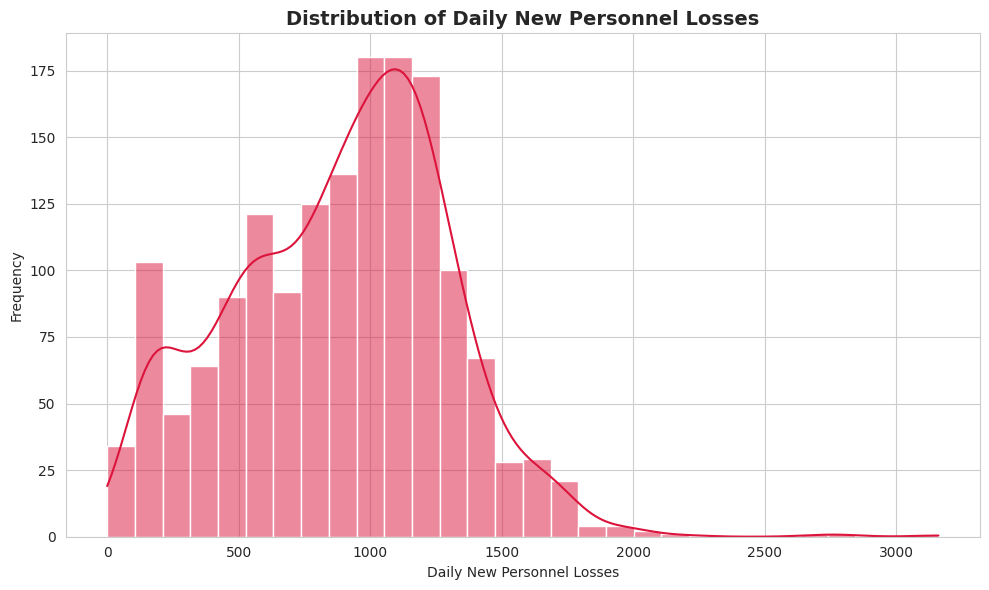

In [38]:
# هستوغرام لتوزيع الخسائر البشرية اليومية الجديدة
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['personnel_daily_new'], bins=30, kde=True, color='crimson', ax=ax)
ax.set_title('Distribution of Daily New Personnel Losses', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily New Personnel Losses')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Countplot — Top 10 most-reported "greatest losses direction" locations**

/tmp/ipykernel_827/2040541114.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directions.values, y=top_directions.index, palette='rocket', ax=ax)


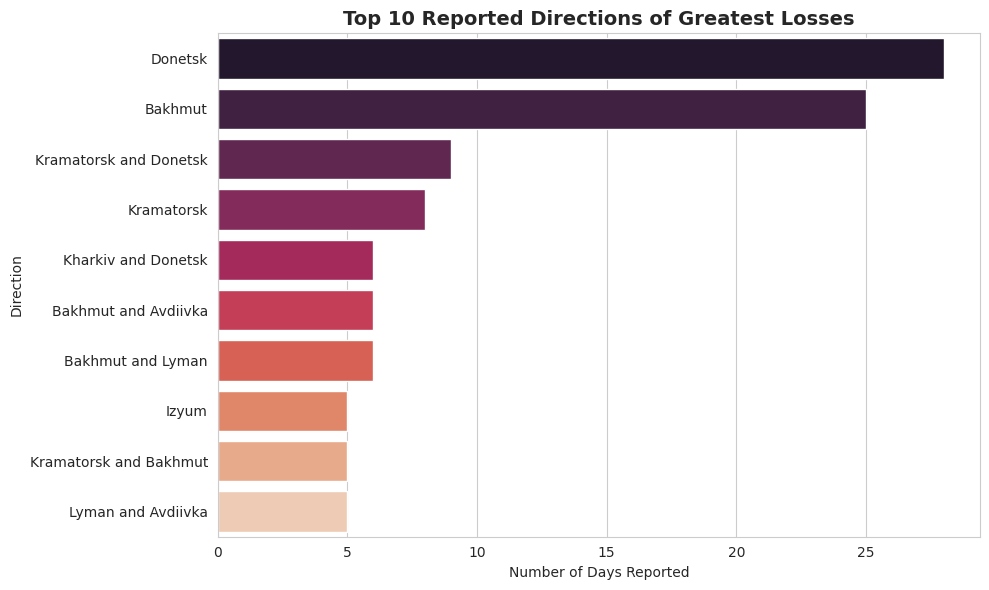

In [39]:
# أكثر 10 مناطق ذُكرت كأكبر مناطق خسائر (باستثناء القيم غير المعروفة)
top_directions = df[df['greatest_losses_direction'] != 'Unknown']['greatest_losses_direction'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_directions.values, y=top_directions.index, palette='rocket', ax=ax)
ax.set_title('Top 10 Reported Directions of Greatest Losses', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Days Reported')
ax.set_ylabel('Direction')
plt.tight_layout()
plt.show()

**Boxplot — Daily new equipment losses (for outlier detection)**

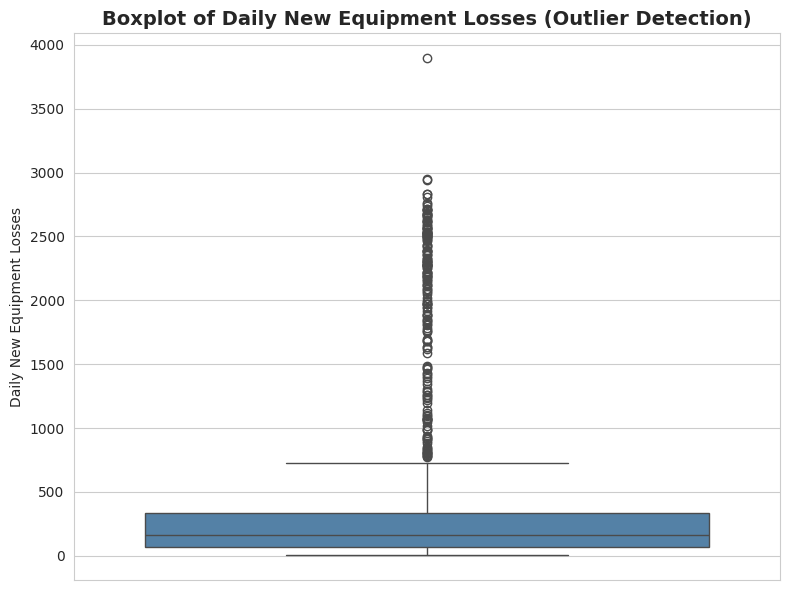

Number of outlier days: 194


,date,equipment_daily_new
1528,2026-05-03,3895
1577,2026-06-21,2946
1472,2026-03-08,2938
1571,2026-06-15,2831
1576,2026-06-20,2830
1512,2026-04-17,2808
1497,2026-04-02,2761
1563,2026-06-07,2753
1489,2026-03-25,2738
1569,2026-06-13,2712


In [40]:
# بوكسبلوت للخسائر اليومية الجديدة للمعدات لاكتشاف القيم المتطرفة (outliers)
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(y=df['equipment_daily_new'], color='steelblue', ax=ax)
ax.set_title('Boxplot of Daily New Equipment Losses (Outlier Detection)', fontsize=14, fontweight='bold')
ax.set_ylabel('Daily New Equipment Losses')
plt.tight_layout()
plt.show()

# حساب نطاق IQR وتحديد الأيام المتطرفة (خارج الحد الأعلى)
q1, q3 = df['equipment_daily_new'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outlier_days = df[df['equipment_daily_new'] > upper_bound][['date', 'equipment_daily_new']].sort_values('equipment_daily_new', ascending=False)
print(f"Number of outlier days: {len(outlier_days)}")
outlier_days.head(10)

### 5.2 Bivariate & Multivariate Analysis

**Scatter Plot — Relationship between daily personnel losses and daily equipment losses**

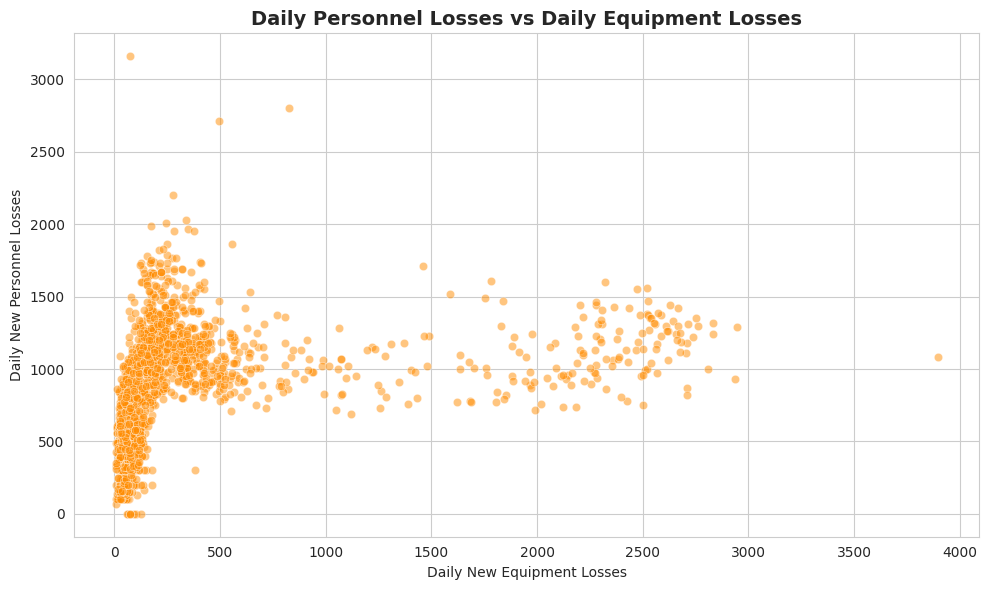

Correlation coefficient: 0.31


In [41]:
# رسم انتشار (scatter) للعلاقة بين الخسائر البشرية اليومية والخسائر المادية اليومية
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='equipment_daily_new', y='personnel_daily_new', alpha=0.5, color='darkorange', ax=ax)
ax.set_title('Daily Personnel Losses vs Daily Equipment Losses', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily New Equipment Losses')
ax.set_ylabel('Daily New Personnel Losses')
plt.tight_layout()
plt.show()

# حساب معامل الارتباط بين المتغيرين
correlation = df['equipment_daily_new'].corr(df['personnel_daily_new'])
print(f"Correlation coefficient: {correlation:.2f}")

**Line Plot — Cumulative losses over time (Personnel vs Total Equipment)**

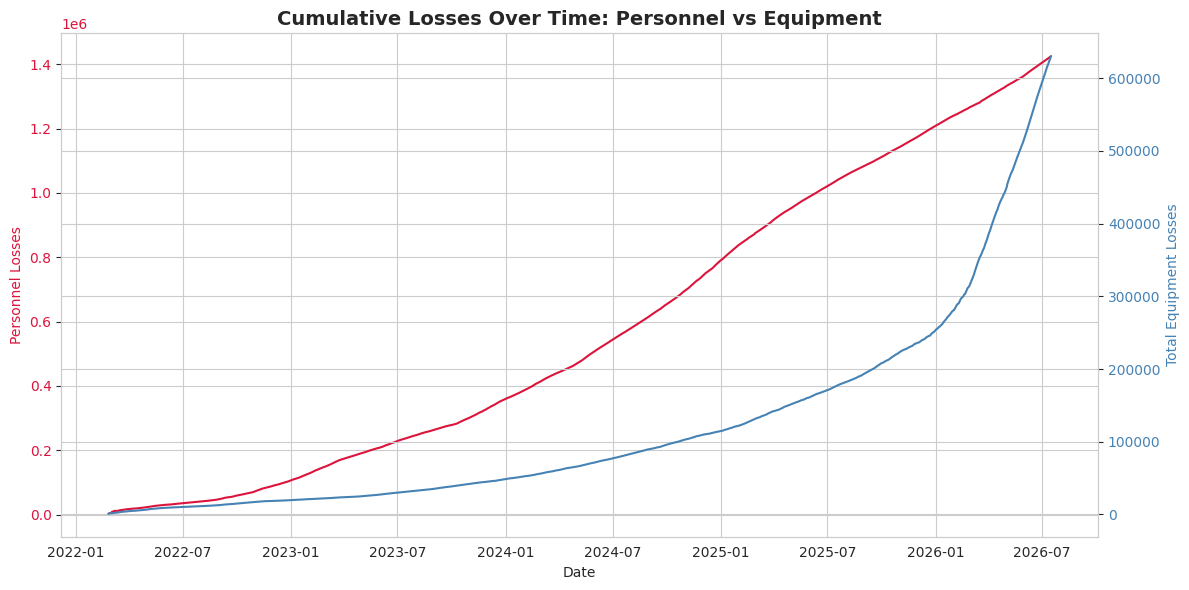

In [42]:
# رسم خطي بمحورين (dual axis) لتطور الخسائر التراكمية عبر الزمن
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df['date'], df['personnel'], color='crimson', label='Personnel (cumulative)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Personnel Losses', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')

ax2 = ax1.twinx()
ax2.plot(df['date'], df['total_equipment_losses'], color='steelblue', label='Equipment (cumulative)')
ax2.set_ylabel('Total Equipment Losses', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Cumulative Losses Over Time: Personnel vs Equipment', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

**Bar Plot — Total losses by equipment category (latest data snapshot)**

/tmp/ipykernel_827/3593867943.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=equipment_totals.values, y=equipment_totals.index, palette='mako', ax=ax)


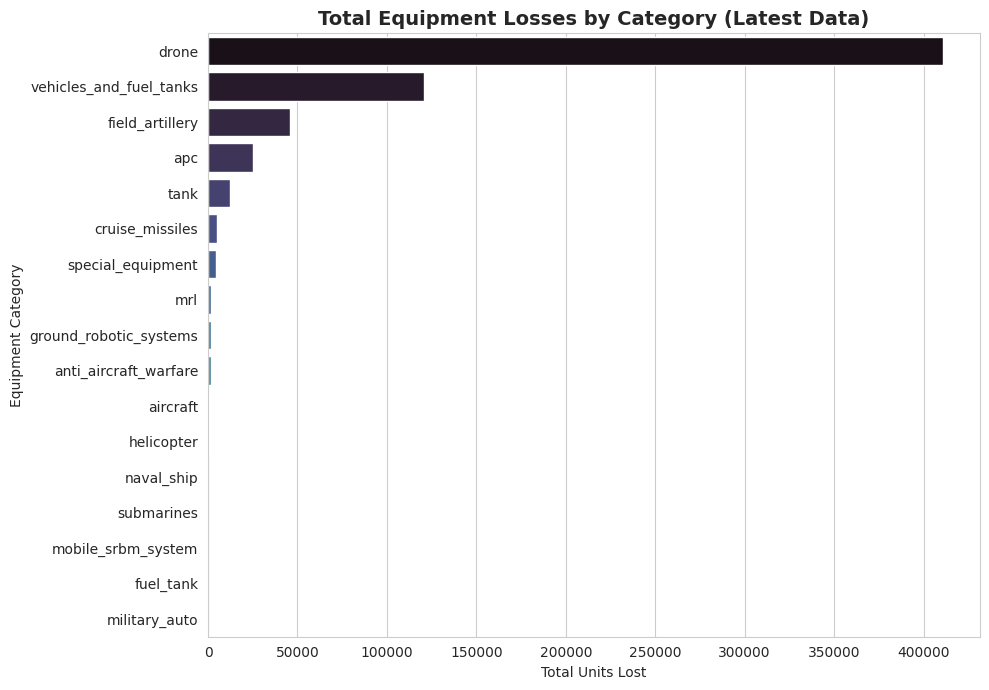

In [43]:
# مخطط أعمدة أفقي لإجمالي الخسائر حسب فئة المعدات (آخر يوم متوفر بالبيانات)
latest = df.iloc[-1]
equipment_totals = latest[equip_numeric_cols].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=equipment_totals.values, y=equipment_totals.index, palette='mako', ax=ax)
ax.set_title('Total Equipment Losses by Category (Latest Data)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Units Lost')
ax.set_ylabel('Equipment Category')
plt.tight_layout()
plt.show()

**Correlation Heatmap — Relationship between different equipment categories (Multivariate)**

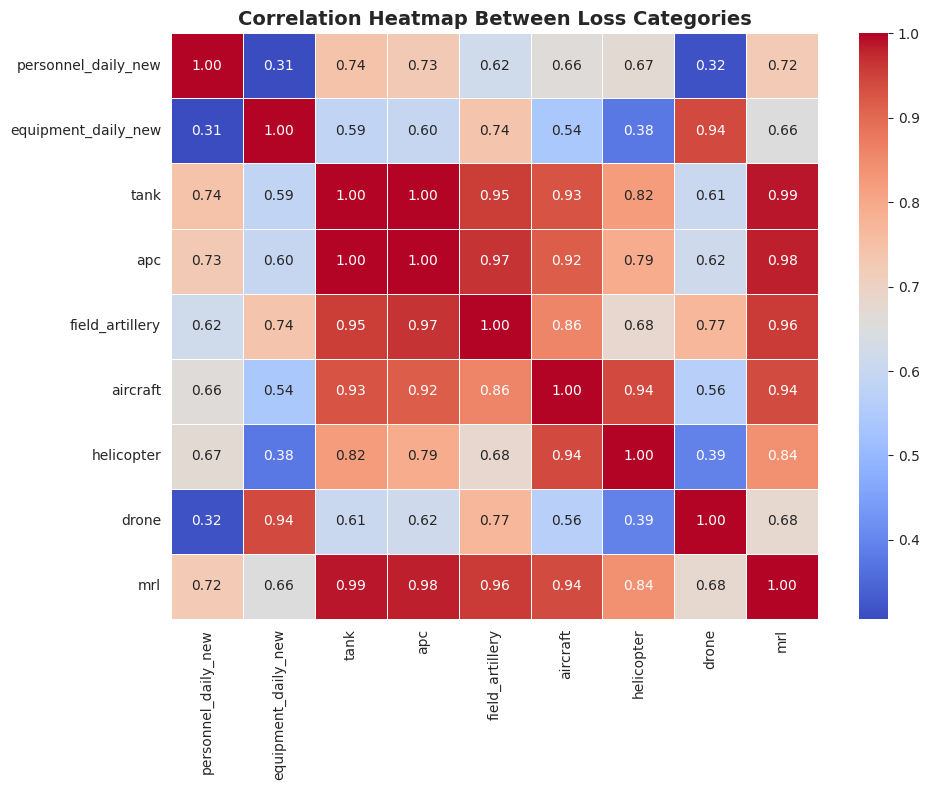

In [44]:
# خريطة حرارية (heatmap) للارتباط بين فئات الخسائر المختلفة
corr_cols = ['personnel_daily_new', 'equipment_daily_new', 'tank', 'apc',
             'field_artillery', 'aircraft', 'helicopter', 'drone', 'mrl']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap Between Loss Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Insights Summary

**Patterns Discovered:**
- Cumulative losses (both personnel and equipment) show near-continuous growth across the entire time period, but the **daily rate** (daily new losses) fluctuates significantly and is far from constant — reflecting varying intensity of fighting from day to day.
- The distribution of daily personnel losses is right-skewed: most days show moderate losses, while a small number of days show very high losses.

**Interesting Relationships:**
- There is a clear positive correlation between land-based equipment categories (tanks and APCs), since they are typically used together in the same ground battles.
- The correlation between daily personnel losses and daily equipment losses exists but is only moderate — suggesting that battles with heavy equipment losses don't always come with proportionally heavy personnel losses (and sometimes the reverse).

**Outliers:**
- Several "outlier" days were identified with equipment losses far exceeding the normal average (outside the IQR × 1.5 range) — these days often correspond to major battles widely covered in the media (such as battles around Bakhmut, Avdiivka, and others, based on the `greatest_losses_direction` column).

**Key Takeaways:**
- The data reflects a long, ongoing war with phases of varying intensity, not a single instantaneous event.
- Donetsk and Bakhmut are the most frequently reported directions of greatest losses, reflecting the concentration of intense ground fighting in eastern Ukraine.


## Step 7: Interactive Dashboard (Streamlit)

A full interactive, **bilingual (English / Arabic)** dashboard was built using **Streamlit** as a multi-page app inside `streamlit_app/`:

```
streamlit_app/
├── app.py                        # Overview page: banner, KPI cards, weekly comparison, annotated timeline
├── common.py                     # Shared code: data loading, translations, sidebar filters
└── pages/
    ├── 1_📊_Deep_Analysis.py     # Category comparisons, correlation heatmap, predictive model
    └── 2_🗺️_Interactive_Map.py   # Searchable + animated map of combat directions
```

**Sidebar (shared across all pages), including a full explanation of each filter:**

| Filter | Type | What it does |
|---|---|---|
| Language / اللغة | Dropdown | Switches every label, header and caption in the dashboard between English and Arabic. |
| Start Date / End Date | Date pickers | Restricts every chart, KPI, and the map to only the days within this range. |
| Equipment Categories to Compare | **Multiselect** | Chooses which equipment types appear in the multi-line comparison chart and the correlation heatmap. |
| Equipment Category for Trend Chart | **Dropdown** | Picks a single category to show its own daily-new-losses bar chart. |
| Minimum Daily Personnel Losses | **Slider** | Filters the whole dashboard down to days where at least this many personnel losses were reported *on that single day* (not the running cumulative total). Raising it isolates unusually severe days — e.g. major battles — so the charts and map narrow down to just those days. Set it back to 0 to see all days again. |

**Overview page:** gradient banner, color-coded KPI cards, a "This Week vs. Last Week" comparison, and a cumulative-losses timeline annotated with 5 major reported battles.

**Deep Analysis page:** multi-category comparison chart, single-category daily trend, totals-by-category bar chart, a colorblind-friendly correlation heatmap, and a simple linear-regression **predictive model** with an adjustable forecast-horizon slider.

**Interactive Map page:** a searchable, geocoded map of combat directions mentioned in `greatest_losses_direction`, plus a month-by-month **animated map** (▶ play) showing how reported hotspots shift over time.

**Live data:** the app fetches the latest data directly from GitHub every time it loads (cached for 1 hour), with automatic fallback to the locally saved `clean_data.csv` if the connection fails — so the dashboard never breaks and always shows the freshest data available.

**Light/Dark mode:** handled by Streamlit's own built-in theme switcher (☰ menu → Settings → Theme) instead of a custom in-app toggle, to avoid conflicting with it.

To run the app locally:
```bash
cd streamlit_app
pip install -r requirements.txt
streamlit run app.py
```


## Step 8: Final Summary

**Main Insights:**
1. The Russia-Ukraine war shows officially documented, continuously growing losses across more than 1600 days of fighting, with clear variation in the intensity of daily losses depending on the war's phase.
2. There is a strong correlation between land equipment categories (tanks, APCs, artillery), and a comparatively weaker correlation between equipment losses and personnel losses.
3. A number of days stand out as "exceptional days" with losses well above the normal average, reflecting specific major battles tied to particular times and locations, several of which can now be located directly on the dashboard's interactive map.

**What I Learned:**
- How to handle real, "messy" data containing gaps caused by changes in the data-collection methodology itself (a category being discontinued and merged into another), not just random missing values.
- The importance of converting cumulative data into daily data to understand real patterns and trends, since cumulative data alone hides important fluctuations.
- How to build an interactive, bilingual dashboard that connects exploratory analysis with the final presentation for the end user, including geocoding free-text location mentions for map visualization.

**Limitations of the Dataset:**
- The data relies on a single source (the Ukrainian military), and there is a possibility of bias or exaggeration in the reported figures from any party in an ongoing war (the "fog of war"), with no corresponding official data from the Russian side for comparison.
- Some categories stopped being tracked or changed classification over time (such as POW and military auto), reducing the ability to directly compare those specific categories across the entire time period.
- The `greatest_losses_direction` column is unstructured free text (sometimes containing more than one location in a single value), which required text parsing and manual geocoding for the map, and is only reported on a minority of days overall.

**Recommendations for Future Analysis:**
- Combine this dataset with geographic sources for more precise, front-line-level spatial analysis instead of city-level approximations.
- Add economic data or the missile attacks dataset (from the same source) for a deeper analysis of the relationship between the air war and ground losses.

